<a href="https://colab.research.google.com/github/emgakii001/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emgakii001/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [12]:
!git clone https://github.com/emgakii001/flyrank-ml-internship.git
%cd flyrank-ml-internship


Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 159 (delta 63), reused 92 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 1.87 MiB | 16.69 MiB/s, done.
Resolving deltas: 100% (63/63), done.
/content/flyrank-ml-internship/flyrank-ml-internship


In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["needs_review"] = (df["trend_direction"] == "down").astype(int)

model_features = ["impressions_90d", "clicks_90d", "ctr", "avg_position",
                   "engagement_rate", "content_age_days"]

# Recreate the grouped split + trained model from Week 5/6
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

X_train = train_df[model_features].fillna(0)
y_train = train_df["needs_review"]
X_test = test_df[model_features].fillna(0)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

test_df["model_score"] = model.predict_proba(X_test)[:, 1]
print(f"Model trained. Test set: {len(test_df)} pages")

Model trained. Test set: 6163 pages


## **1. Ranked actions + reason codes**

For this playbook, I combined two things I built earlier in the track: the model's prediction score from Week 5, and the reason-code logic from my Week 4 baseline rule.

I chose to rank pages by the model's score rather than the rule's score, because Week 5 and Week 6 both showed the model is a more accurate predictor (Precision@50 of 0.740 versus the rule's 0.460, confirmed again under an honest grouped split in Week 6). But I kept the rule's reason codes attached to each page, because a raw model probability doesn't tell a human reviewer why a page was flagged only the rule's logic (staleness, low CTR relative to position, or both) gives a reviewer something concrete to check.

Each page in the queue gets three things: a model score (used for ranking), a reason code (STALE_CONTENT, LOW_CTR_FOR_POSITION, both, or MODEL_SCORE_ONLY if the model flagged it independently of either rule condition), and an action label (REVIEW if the model score is 0.5 or higher, otherwise MONITOR). This way, the ranking benefits from the model's stronger accuracy, while the reason codes keep every recommendation explainable, a reviewer never has to trust a bare number without knowing what's behind it.

One thing worth naming: some pages will show reason code MODEL_SCORE_ONLY:  meaning the model flagged them as high-priority even though neither of my two hand-written rule conditions triggered. These are the cases where the model is picking up on a combination of signals (like the mix of impressions, clicks, and engagement) that a single-threshold rule simply can't see. These pages deserve a closer human look, since I can't yet explain why the model ranked them highly beyond "the combination of features suggested it."

In [14]:
# Reason codes — same logic as Week 4 baseline
test_df["flag_stale"] = (test_df["freshness_tier"] == "91-180")
tier_avg_ctr = test_df.groupby("position_tier")["ctr"].transform("mean")
test_df["flag_low_ctr"] = (test_df["ctr"] / tier_avg_ctr) < 0.14

def get_reason_code(row):
    if row["flag_stale"] and row["flag_low_ctr"]:
        return "STALE_CONTENT + LOW_CTR_FOR_POSITION"
    elif row["flag_stale"]:
        return "STALE_CONTENT"
    elif row["flag_low_ctr"]:
        return "LOW_CTR_FOR_POSITION"
    else:
        return "MODEL_SCORE_ONLY"

test_df["reason_code"] = test_df.apply(get_reason_code, axis=1)
test_df["action"] = test_df["model_score"].apply(lambda x: "REVIEW" if x >= 0.5 else "MONITOR")

# Rank by MODEL score (more accurate than the rule alone)
playbook_queue = test_df.sort_values("model_score", ascending=False).reset_index(drop=True)

print(playbook_queue[["content_id", "model_score", "reason_code", "action"]].head(10).to_string())

             content_id  model_score           reason_code  action
0  content_c84a0ab98e90     0.796071  LOW_CTR_FOR_POSITION  REVIEW
1  content_453722754fea     0.764699  LOW_CTR_FOR_POSITION  REVIEW
2  content_39881853ef0c     0.747500  LOW_CTR_FOR_POSITION  REVIEW
3  content_73c54f78c06a     0.733112      MODEL_SCORE_ONLY  REVIEW
4  content_8d3971bfd976     0.732415      MODEL_SCORE_ONLY  REVIEW
5  content_865fd632a1f3     0.696120  LOW_CTR_FOR_POSITION  REVIEW
6  content_f6ae0f36d70d     0.695215  LOW_CTR_FOR_POSITION  REVIEW
7  content_a5dbb404bdc2     0.694073         STALE_CONTENT  REVIEW
8  content_d55b83aff7c7     0.687429      MODEL_SCORE_ONLY  REVIEW
9  content_d0cadc3e2773     0.685698      MODEL_SCORE_ONLY  REVIEW


## **2. Intended use and limits**


This playbook is intended for content editors and SEO/review teams to help decide which pages should be prioritized for human review and possible refresh or optimization. It should be used as a decision-support tool to rank review candidates and provide reason codes that help reviewers investigate each page, but it should not be treated as an automatic verdict that a page needs a specific content action. The playbook was trained and evaluated on the 32 clients in the available dataset, so its performance should not be assumed to generalize to brand-new clients or clients with substantially different content types. It also relies on a proxy `needs_review` label based on observed trend information rather than verified expert judgments, and the historical model may not account for seasonal effects or future changes in search behavior, algorithms, or market conditions. Finally, pages with missing engagement data or other structural data gaps should be interpreted carefully, and human reviewers should be able to override the model when the score conflicts with clear page-level evidence.


In [15]:
# Section 2 — intended use and limits, documented for reuse in the paper

intended_use = {
    "who": "Content editors and SEO/review teams",
    "decision_supported": "Which pages to prioritize for human review and possible refresh",
    "appropriate_use": "Ranking review candidates with reason codes for investigation",
    "not_for": "Automatic verdict or fully automated content action",
    "limits": [
        "Trained/evaluated only on the 32 clients in this dataset — not guaranteed to generalize to new clients or content types",
        "needs_review is a proxy label from observed trend data, not verified expert judgment",
        "Historical model does not account for seasonality or future algorithm/market shifts",
        "Pages with missing engagement data (e.g., no GA4 connection) should be interpreted cautiously",
        "Human reviewers should override the model when the score conflicts with clear page-level evidence"
    ]
}

print(f"Who: {intended_use['who']}")
print(f"Decision supported: {intended_use['decision_supported']}")
print(f"\nLimits:")
for limit in intended_use["limits"]:
    print(f"  - {limit}")

Who: Content editors and SEO/review teams
Decision supported: Which pages to prioritize for human review and possible refresh

Limits:
  - Trained/evaluated only on the 32 clients in this dataset — not guaranteed to generalize to new clients or content types
  - needs_review is a proxy label from observed trend data, not verified expert judgment
  - Historical model does not account for seasonality or future algorithm/market shifts
  - Pages with missing engagement data (e.g., no GA4 connection) should be interpreted cautiously
  - Human reviewers should override the model when the score conflicts with clear page-level evidence


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on any REVIEW-flagged page, a human should check the reason code against the actual page, confirm that the decline is not caused by seasonality, investigate possible technical issues such as broken links when CTR is unusually low, and verify that the underlying data is complete enough to support the recommendation. Additionally, the following should never be automated without human review: publishing or editing content based on the model score alone, acting on `MODEL_SCORE_ONLY` flags without understanding why the model ranked the page highly, and taking action on pages with known data gaps without extra scrutiny, because the model provides a prioritization signal rather than a guaranteed diagnosis or decision.


In [16]:
# Section 3 — human review checklist and no-go list

human_review_checklist = [
    "Check the reason code against the actual page (e.g., is it genuinely stale, or was it recently updated but not yet reflected in the data?)",
    "Confirm the decline is not explained by seasonality",
    "Investigate possible technical issues (e.g., a CTR of 0.00% may indicate a broken link, not a content problem)",
    "Verify the underlying data is complete enough to support the recommendation (e.g., check for GA4 availability)"
]

no_go_list = [
    "Never publish or edit content automatically based on the model score alone",
    "Never act on MODEL_SCORE_ONLY flags without understanding why the model ranked the page highly",
    "Never take action on pages from clients with known data gaps without extra scrutiny"
]

print("HUMAN REVIEW CHECKLIST (before acting on any REVIEW-flagged page):")
for item in human_review_checklist:
    print(f"  - {item}")

print("\nNO-GO LIST (never automated without human review):")
for item in no_go_list:
    print(f"  - {item}")

HUMAN REVIEW CHECKLIST (before acting on any REVIEW-flagged page):
  - Check the reason code against the actual page (e.g., is it genuinely stale, or was it recently updated but not yet reflected in the data?)
  - Confirm the decline is not explained by seasonality
  - Investigate possible technical issues (e.g., a CTR of 0.00% may indicate a broken link, not a content problem)
  - Verify the underlying data is complete enough to support the recommendation (e.g., check for GA4 availability)

NO-GO LIST (never automated without human review):
  - Never publish or edit content automatically based on the model score alone
  - Never act on MODEL_SCORE_ONLY flags without understanding why the model ranked the page highly
  - Never take action on pages from clients with known data gaps without extra scrutiny


## 4. Monitoring / retrain triggers

For this playbook, the recommendations should be revisited if Precision@50 drops noticeably below the Week 5/6 results, the distribution of reason codes changes dramatically, or the data-source and client coverage changes. These triggers matter because they may indicate that the underlying patterns have shifted, meaning the model is no longer performing as reliably on the data it was trained on. I would also schedule a re-evaluation after a full seasonal cycle to check whether seasonal changes affect the recommendations.

In [17]:
# Section 4 — monitoring and retrain triggers

monitoring_triggers = [
    "Precision@50 drops noticeably below the Week 5/6 baseline (0.557-0.740 range)",
    "Reason code distribution shifts dramatically from what was observed in this notebook",
    "Data-source coverage changes (e.g., clients gaining or losing GA4/GSC connections)",
    "New clients are onboarded outside the 32 clients this model was validated on",
    "A full seasonal cycle has passed since the last evaluation"
]

print("MONITORING / RETRAIN TRIGGERS:")
for trigger in monitoring_triggers:
    print(f"  - {trigger}")

print("\nWhy these matter: each signals that the underlying data patterns may have")
print("shifted, meaning the model's original validation no longer reflects current")
print("conditions — a reason to re-evaluate before continuing to trust the playbook.")

MONITORING / RETRAIN TRIGGERS:
  - Precision@50 drops noticeably below the Week 5/6 baseline (0.557-0.740 range)
  - Reason code distribution shifts dramatically from what was observed in this notebook
  - Data-source coverage changes (e.g., clients gaining or losing GA4/GSC connections)
  - New clients are onboarded outside the 32 clients this model was validated on
  - A full seasonal cycle has passed since the last evaluation

Why these matter: each signals that the underlying data patterns may have
shifted, meaning the model's original validation no longer reflects current
conditions — a reason to re-evaluate before continuing to trust the playbook.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

This section produces the concrete files my capstone paper will build on next week.

**Part 1**: Ranked queue CSV: exports the full playbook queue (work/outputs/baseline_action_score.csv), including each page's model score, reason code, action label, and the supporting signals (freshness tier, position tier, CTR, impressions) used to justify it. This file is regenerated every time the notebook runs and is not committed to git, per the project's data-file policy.

**Part 2**: Model vs. baseline figure: saves a bar chart (work/figures/model_vs_baseline.png) comparing the Week 4 rule-based baseline against the Week 5 model on Precision@50. This is the single clearest visual for the paper's Results section, showing the improvement from 0.460 to 0.740 at a glance.

**Part 3**: Metrics JSON: saves the key numbers from across the track (work/outputs/w07_metrics.json), baseline and model precision, the naive-vs-grouped split AUC comparison from Week 6, the leakage-trap demonstration score, and the final queue size. This file is committed to the repo and serves as the factual record my paper's numbers will trace back to, so any claim in the final paper can be checked against this source.

In [18]:
import os

os.makedirs("work/outputs", exist_ok=True)

# Final playbook queue with all the pieces from Section 1
export_columns = ["content_id", "client_id", "model_score", "reason_code", "action",
                   "freshness_tier", "position_tier", "ctr", "impressions_90d"]

playbook_queue[export_columns].to_csv("work/outputs/baseline_action_score.csv", index=False)

print(f"Exported {len(playbook_queue)} rows to work/outputs/baseline_action_score.csv")
print(playbook_queue[export_columns].head())

Exported 6163 rows to work/outputs/baseline_action_score.csv
             content_id          client_id  model_score           reason_code  \
0  content_c84a0ab98e90  client_f369cb89fc     0.796071  LOW_CTR_FOR_POSITION   
1  content_453722754fea  client_f369cb89fc     0.764699  LOW_CTR_FOR_POSITION   
2  content_39881853ef0c  client_f369cb89fc     0.747500  LOW_CTR_FOR_POSITION   
3  content_73c54f78c06a  client_f369cb89fc     0.733112      MODEL_SCORE_ONLY   
4  content_8d3971bfd976  client_f369cb89fc     0.732415      MODEL_SCORE_ONLY   

   action freshness_tier position_tier   ctr  impressions_90d  
0  REVIEW           0-30        page_1  0.03           223271  
1  REVIEW           0-30        page_1  0.01           140079  
2  REVIEW           0-30        page_1  0.01           112434  
3  REVIEW           0-30        page_1  0.10           213963  
4  REVIEW           0-30      page_3_5  0.03            98924  


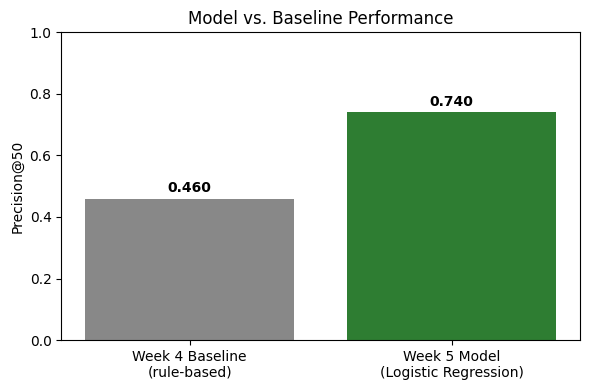

Saved figure to work/figures/model_vs_baseline.png


In [19]:
import matplotlib.pyplot as plt
import os

os.makedirs("work/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 4))
methods = ["Week 4 Baseline\n(rule-based)", "Week 5 Model\n(Logistic Regression)"]
scores = [0.460, 0.740]  # from your Week 5 results

ax.bar(methods, scores, color=["#888888", "#2E7D32"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs. Baseline Performance")
ax.set_ylim(0, 1)
for i, v in enumerate(scores):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=150)
plt.show()

print("Saved figure to work/figures/model_vs_baseline.png")

In [20]:
import json

metrics = {
    "baseline_precision_at_50": 0.460,
    "model_precision_at_50": 0.740,
    "naive_split_auc": 0.595,
    "grouped_split_auc": 0.557,
    "leaky_auc_demonstration": 1.000,
    "queue_size": len(playbook_queue),
    "review_flagged_count": int((playbook_queue["action"] == "REVIEW").sum())
}

with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics to work/outputs/w07_metrics.json")
print(json.dumps(metrics, indent=2))

Saved metrics to work/outputs/w07_metrics.json
{
  "baseline_precision_at_50": 0.46,
  "model_precision_at_50": 0.74,
  "naive_split_auc": 0.595,
  "grouped_split_auc": 0.557,
  "leaky_auc_demonstration": 1.0,
  "queue_size": 6163,
  "review_flagged_count": 3484
}


In [21]:
!git config --global user.email "your-email@example.com"
!git config --global user.name "emgakii001"
!git add work/figures/model_vs_baseline.png work/outputs/w07_metrics.json
!git commit -m "Add Week 7 playbook figure and metrics"

[main 89b1fb7] Add Week 7 playbook figure and metrics
 2 files changed, 9 insertions(+)
 create mode 100644 work/figures/model_vs_baseline.png
 create mode 100644 work/outputs/w07_metrics.json


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.